# 04 · Inferencia causal — efecto de la sequía sobre el rendimiento

## Diseño

| elemento | definición |
|---|---|
| **Unidad de observación** | Municipio × Año agrícola × Ciclo (OI/PV). Cada unidad se observa además por **modalidad hídrica** (Riego / Temporal); el tratamiento es idéntico para las dos filas de un mismo municipio‑ciclo. |
| **Tratamiento** `trat` (binario) | `1` si `nivel_sequia_max ∈ {1,2,3,4}` (D1–D4). `0` si `nivel_sequia_max ∈ {0, -1, no clasificado}`. |
| **Resultado** `Y` | `rendimiento_real` (t/ha), excluyendo cosecha total nula y **tasa de siniestro ≥ 50 %** (`siniestrada/sembrada`, corte fijo; columna `siniestro_ok` de `02_join_data` — ver `03_EDA` §2.6‑2.8). Análisis primario en `log(rendimiento_real)` por la asimetría. |
| **Moderador** | `nommodalidad` (Riego / Temporal) — efecto **condicional** por estrato (CATE). |
| **Colisionador / mediador** `superficie_cosechada` (`cosechada`) | La sequía reduce la superficie cosechada vía siniestros, y `cosechada` **es el denominador** de `rendimiento_real` (`Y = volumen / cosechada`). Condicionarla bloquea parte del efecto y puede abrir sesgo de colisionador. **Fuera del conjunto de ajuste**; la §8 cuantifica el sesgo. |

### Conjunto de ajuste — criterio y justificación causal/temporal

Una variable entra al conjunto de ajuste solo si **(a)** no es efecto del tratamiento del ciclo actual (precedencia temporal o argumento explícito de exogeneidad) y **(b)** afecta a `Y` por una vía distinta a `trat` (no es un mediador). La sola asociación estadística con tratamiento y resultado (SMD, correlación) es condición necesaria pero no suficiente — por eso cada bloque se clasifica según qué tan defendible es su precedencia temporal, en vez de listarlas todas al mismo nivel.

**Estrictamente pre‑tratamiento (sin ambigüedad)**
- `nivel_sequia_prev90_max` — sequía máxima en los ~90 días *previos* al inicio del ciclo; por construcción termina antes de que empiece la ventana de `trat`. Captura el régimen persistente de sequía de la región (→ prob. de sequía en el ciclo, ρ≈0.47 con `trat`) y la humedad de arranque del suelo (→ rendimiento). Se acompaña de `sequia_prev90_no_clasificada` (indicador de imputación, ~26 % de las filas).
- `altitud_media_m`, `altitud_std_m`, `tmean_normal` — atributos físicos fijos del municipio (relieve, climatología histórica); no pueden ser efecto de un ciclo agrícola particular.

**Concurrentes con el ciclo, defendidas como exógenas (no como pre‑tratamiento)**
- `tmean_ciclo_anom`, `dias_helada`, `tmean_prev90_anom` — se miden en la misma ventana que `trat` o justo antes. Se defienden como confusores y no como mediadores porque el mecanismo físico por el que afectan el rendimiento (estrés térmico/heladas sobre el cultivo) es **distinto** del mecanismo de la sequía (déficit de humedad de suelo), y ambos comparten un origen climático común aguas arriba (p. ej. patrones de circulación de gran escala) sin que uno cause directamente al otro. Este es el eslabón más débil de la justificación temporal — no se puede probar solo con los datos disponibles; queda como supuesto de diseño explícito, no implícito.

**Estructurales, con una advertencia de endogeneidad no resuelta**
- `acuifero_disp`, `cuencas_disp`, `tiene_acuifero_sobreexplotado`, `tiene_cuenca_sin_disp` — clasificaciones **administrativas** de CONAGUA (no mediciones meteorológicas), asignadas al panel con la regla "año‑fuente más próximo ≤ año" porque CONAGUA solo publica estas clasificaciones cada 2‑3 años (acuíferos: 2015/2018/2020/2023; cuencas: 2016/2020/2023). Esto abre una duda real de identificación: si una sequía prolongada reduce la recarga de un acuífero y CONAGUA lo reclasifica como sobreexplotado en, digamos, 2020, esa reclasificación se asigna retroactivamente a los años 2020+ del panel como "confusor" — pero podría ser parcialmente una **consecuencia acumulada de sequía pasada**, no una causa independiente. Es decir, no puede garantizarse el criterio (a) para estas variables: podrían estar parcialmente en la vía causal de `trat` de ciclos anteriores hacia `Y`. Se mantienen en el conjunto de ajuste principal porque siguen siendo el mejor proxy disponible de vulnerabilidad hídrica estructural, pero con esta reserva explícita. El diagnóstico de balance (§4) ya muestra que son, junto con los años de prevalencia de tratamiento extrema, las variables que más desbalance residual dejan tras la ponderación — no es casualidad. *Caveat adicional*: `tiene_acuifero_sobreexplotado` no es confiable en 2016‑2019 (CONAGUA no publicó la columna `Condición` en esas fuentes; ver `acuifero_condicion_ok`).
- **Escala productiva**: `log(sembrada)` — se fija al inicio del ciclo, en principio antes de que se conozca el nivel de sequía que tendrá el ciclo. Advertencia: si los productores anticipan condiciones secas (por ejemplo, a partir de la sequía antecedente ya observada) y por eso siembran menos superficie, `sembrada` dejaría de ser un confusor limpio y pasaría a ser parcialmente un **control malo** (afectado por la misma información que predice `trat`). No puede descartarse solo con los datos disponibles.

**Estructura**: EF de **año** y (en la especificación de panel) de **municipio**; `nomcicloproductivo`; `nommodalidad`.

**Se excluyen** por post‑tratamiento / mecánicos del resultado: `siniestrada`, `cosechada`, `volumenproduccion`, `valorproduccion`, `precio_*`, `n_dias_*`, `ventana_incompleta`; y `gdd_anom` por redundancia con `tmean_ciclo_anom` (ρ ≈ 0.99).

### Identificación

**Ignorabilidad condicional** dado el conjunto de ajuste (+ EF) — supuesto que, como se detalla arriba, es más defendible para unas variables que para otras (fuerte para la sequía antecedente y los atributos fijos; más débil para las variables hídricas estructurales y `log(sembrada)`). Se reportan cuatro estimadores del ATE (diferencia cruda, regresión/g‑cómputo, IPW y AIPW doblemente robusto con cross‑fitting) más su heterogeneidad por modalidad. Robustez: panel TWFE, log vs niveles, soporte común, tratamiento ordinal, colisionador, E‑value, placebo, sensibilidad a la fiabilidad de las variables hídricas estructurales, y sensibilidad a la violación de positividad de 2023‑2024 (§8). SE agrupadas (cluster) por municipio.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from scipy import stats

RNG = np.random.default_rng(20260905)
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 170)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.grid': True,
                     'grid.alpha': 0.25, 'axes.axisbelow': True})
C_TRT = {'control': '#6b8cbe', 'tratado': '#c0504d'}
C_MOD = {'Riego': '#3b7dd8', 'Temporal': '#e08214'}

RUTA = Path('/Users/jaydymarchan/Desktop/causalidad/data/02_processed/tabla_modelo.csv')
raw = pd.read_csv(RUTA)
print(raw.shape)


(40267, 56)


## 1 · Muestra de análisis

In [2]:
d = raw.copy()

# tratamiento binario: D1-D4 -> 1 ; {0, -1, no clasificado} -> 0
d['trat'] = (d['nivel_sequia_max'] >= 1).astype(int)

# resultado: rendimiento_real ya viene limpio (= volumenproduccion / cosechada, definición SIAP).
# Se dejan fuera: cosecha total nula (rendimiento_real == 0) y tasa de siniestro >= 50%
# (siniestrada/sembrada >= 50%, columna 'siniestro_ok' calculada en 02_join_data).
d['superficie_cosechada'] = d['cosechada']          # alias del COLISIONADOR (no ajustar)
d['Y'] = d['rendimiento_real'].where((d['rendimiento_real'] > 0) & d['siniestro_ok'])
d['logY'] = np.log(d['Y'])
d['log_sembrada'] = np.log(d['sembrada'].clip(lower=0.1))

CONF_NUM = ['nivel_sequia_prev90_max',                 # sequía ANTECEDENTE (90 d previos al ciclo) - pre-tratamiento
            'tmean_ciclo_anom', 'dias_helada', 'tmean_prev90_anom', 'tmean_normal',
            'altitud_media_m', 'altitud_std_m', 'acuifero_disp', 'cuencas_disp', 'log_sembrada']
CONF_BIN = ['tiene_acuifero_sobreexplotado', 'tiene_cuenca_sin_disp',
            'sequia_prev90_no_clasificada']             # indicador de imputación de nivel_sequia_prev90_max (~26%)
CONF_CAT = ['nommodalidad', 'nomcicloproductivo', 'anio']

ok = (d['Y'].notna() & d['clima_ok'] & d['prev90_ok'] & d['altitud_ok'] & d['hidro_ok']
      & d['siniestro_ok'])
dd = d.loc[ok].copy().reset_index(drop=True)
dd['muni'] = dd['idestado'].astype(str).str.zfill(2) + dd['idmunicipio'].astype(str).str.zfill(3)

n_trat = int(dd['trat'].sum())
print('filas totales           :', f'{len(raw):,}')
print('  con rendimiento > 0    :', f"{int((d['rendimiento_real'] > 0).sum()):,}")
print('  - tasa_siniestro >= 50%:', f"{int((~d['siniestro_ok']).sum()):,}", '(excluidas de Y)')
print('  + confusores completos :', f'{len(dd):,}', '  <-- MUESTRA DE ANÁLISIS')
print('municipios              :', f"{dd['muni'].nunique():,}")
print('años                    :', sorted(dd['anio'].unique()))
print('tratados (D1-D4)         :', f'{n_trat:,}', f'({n_trat/len(dd):.1%})')
print('sequía no clasificada    :', f"{int(dd['sequia_no_clasificada'].sum()):,}",
      f"({dd['sequia_no_clasificada'].mean():.1%})  -> tratadas como trat=0")
print()
print(dd.groupby('nommodalidad').agg(n=('trat', 'size'), pct_tratado=('trat', 'mean')).round(3).to_string())


filas totales           : 40,267
  con rendimiento > 0    : 40,098
  - tasa_siniestro >= 50%: 1,020 (excluidas de Y)
  + confusores completos : 39,155   <-- MUESTRA DE ANÁLISIS
municipios              : 2,379
años                    : [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
tratados (D1-D4)         : 22,543 (57.6%)
sequía no clasificada    : 3,987 (10.2%)  -> tratadas como trat=0

                  n  pct_tratado
nommodalidad                    
Riego         15326        0.549
Temporal      23829        0.593


## 2 · Comparación cruda (referencia sesgada)

In [3]:
def dif_cruda(data, y='logY'):
    a = data.loc[data['trat'] == 1, y]
    b = data.loc[data['trat'] == 0, y]
    dif = a.mean() - b.mean()
    se = np.sqrt(a.var() / len(a) + b.var() / len(b))
    return dif, se

print('Diferencia cruda de medias  E[Y|trat=1] - E[Y|trat=0]')
for esc, y in [('log(rendimiento)', 'logY'), ('rendimiento t/ha', 'Y')]:
    dif, se = dif_cruda(dd, y)
    print(f'  {esc:20s}: {dif:+.4f}  (IC95 {dif-1.96*se:+.3f}, {dif+1.96*se:+.3f})')
    for m in ['Riego', 'Temporal']:
        dif, se = dif_cruda(dd[dd['nommodalidad'] == m], y)
        print(f'      {m:10s}      : {dif:+.4f}  (IC95 {dif-1.96*se:+.3f}, {dif+1.96*se:+.3f})')

print()
print('>>> asociación cruda POSITIVA (más sequía ~ más rendimiento): señal de confusión.')
print()
print(dd.pivot_table(index='nommodalidad', columns='trat', values='Y', aggfunc='mean').round(3).to_string())


Diferencia cruda de medias  E[Y|trat=1] - E[Y|trat=0]
  log(rendimiento)    : +0.0765  (IC95 +0.062, +0.091)
      Riego           : +0.1451  (IC95 +0.130, +0.160)
      Temporal        : +0.0972  (IC95 +0.081, +0.114)
  rendimiento t/ha    : +0.4034  (IC95 +0.360, +0.446)
      Riego           : +0.8207  (IC95 +0.748, +0.893)
      Temporal        : +0.3074  (IC95 +0.272, +0.343)

>>> asociación cruda POSITIVA (más sequía ~ más rendimiento): señal de confusión.

trat              0      1
nommodalidad              
Riego         3.994  4.814
Temporal      1.797  2.105


## 3 · Modelo de propensión y soporte común

AUC propensión: 0.861


       mean    min    25%    50%    75%    max
trat                                          
0     0.353  0.018  0.185  0.301  0.486  0.996
1     0.740  0.036  0.558  0.830  0.968  1.000


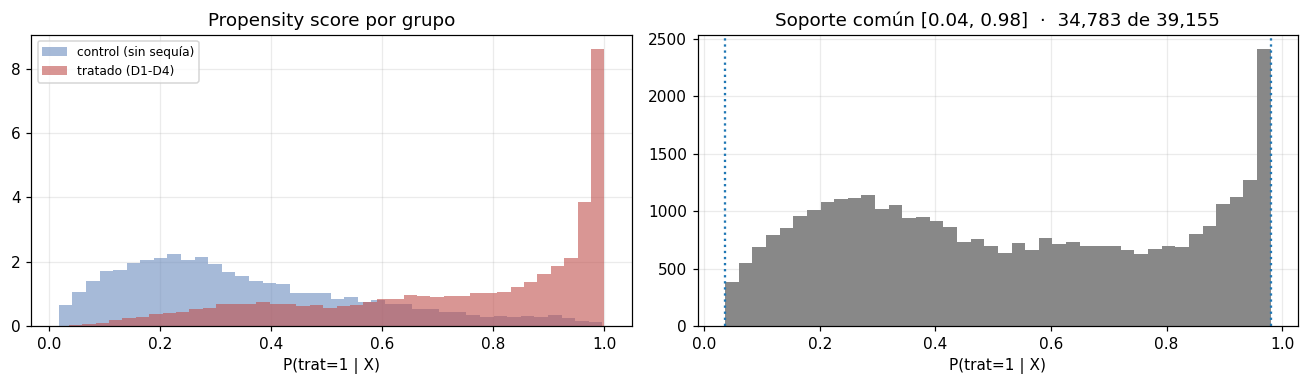

fuera de soporte común: 4,372 (11.2%)


In [4]:
def design(data, scaler=None, fit=False):
    Xn = data[CONF_NUM].to_numpy(float)
    if fit:
        scaler = StandardScaler().fit(Xn)
    Xn = scaler.transform(Xn)
    Xb = data[CONF_BIN].to_numpy(float)
    dumm = pd.get_dummies(data[CONF_CAT].astype(str), drop_first=True)
    names = list(CONF_NUM) + list(CONF_BIN) + list(dumm.columns)
    return np.column_stack([Xn, Xb, dumm.to_numpy(float)]), names, scaler

X, xnames, SCALER = design(dd, fit=True)
trt = dd['trat'].to_numpy()

ps_model = LogisticRegression(max_iter=2000)
ps_model.fit(X, trt)
dd['ps'] = ps_model.predict_proba(X)[:, 1]
print('AUC propensión:', round(roc_auc_score(trt, dd['ps']), 3))
print(dd.groupby('trat')['ps'].describe()[['mean', 'min', '25%', '50%', '75%', 'max']].round(3).to_string())

lo = max(dd.loc[dd['trat'] == 1, 'ps'].min(), dd.loc[dd['trat'] == 0, 'ps'].min(), 0.02)
hi = min(dd.loc[dd['trat'] == 1, 'ps'].max(), dd.loc[dd['trat'] == 0, 'ps'].max(), 0.98)
dd['trim'] = dd['ps'].between(lo, hi)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
for t, lab, c in [(0, 'control (sin sequía)', C_TRT['control']), (1, 'tratado (D1-D4)', C_TRT['tratado'])]:
    ax[0].hist(dd.loc[dd['trat'] == t, 'ps'], bins=40, alpha=0.6, label=lab, color=c, density=True)
ax[0].set_title('Propensity score por grupo'); ax[0].set_xlabel('P(trat=1 | X)'); ax[0].legend(fontsize=8)
ax[1].hist(dd.loc[dd['trim'], 'ps'], bins=40, color='#888')
ax[1].axvline(lo, ls=':'); ax[1].axvline(hi, ls=':')
ax[1].set_title(f'Soporte común [{lo:.2f}, {hi:.2f}]  ·  {int(dd["trim"].sum()):,} de {len(dd):,}')
ax[1].set_xlabel('P(trat=1 | X)')
plt.tight_layout(); plt.show()
print('fuera de soporte común:', f'{int((~dd["trim"]).sum()):,}', f'({(~dd["trim"]).mean():.1%})')


### Diagnóstico: ¿por qué el AUC es alto y hay tanta pérdida de soporte común?

La sequía es un choque climático regional: si en varios años la mayoría de los municipios comparte el mismo
estatus de tratamiento, las dummies de año pueden separar casi perfectamente el modelo de propensión sin que
eso refleje confusión real por las covariables continuas.

In [5]:
tab_anio = dd.groupby('anio')['trat'].agg(n='size', pct_tratado='mean').round(3)
print('% tratados por año:')
print(tab_anio.to_string())
print()

tab_mod = dd.groupby('nommodalidad')['trat'].agg(n='size', pct_tratado='mean').round(3)
print('% tratados por modalidad:')
print(tab_mod.to_string())
print()

# AUC de un modelo de propensión SOLO con año/modalidad/ciclo (sin confusores continuos)
Xcat = pd.get_dummies(dd[CONF_CAT].astype(str), drop_first=True).to_numpy(float)
auc_cat = roc_auc_score(trt, LogisticRegression(max_iter=2000).fit(Xcat, trt).predict_proba(Xcat)[:, 1])
print(f'AUC usando SOLO año/modalidad/ciclo (sin confusores continuos): {auc_cat:.3f}')
print(f'AUC del modelo completo (con confusores continuos)           : {round(roc_auc_score(trt, dd["ps"]), 3)}')

% tratados por año:
         n  pct_tratado
anio                   
2016  4394        0.408
2017  4394        0.404
2018  4346        0.472
2019  4230        0.621
2020  4295        0.503
2021  4421        0.569
2022  4420        0.548
2023  4245        0.776
2024  4410        0.887

% tratados por modalidad:
                  n  pct_tratado
nommodalidad                    
Riego         15326        0.549
Temporal      23829        0.593

AUC usando SOLO año/modalidad/ciclo (sin confusores continuos): 0.687
AUC del modelo completo (con confusores continuos)           : 0.861


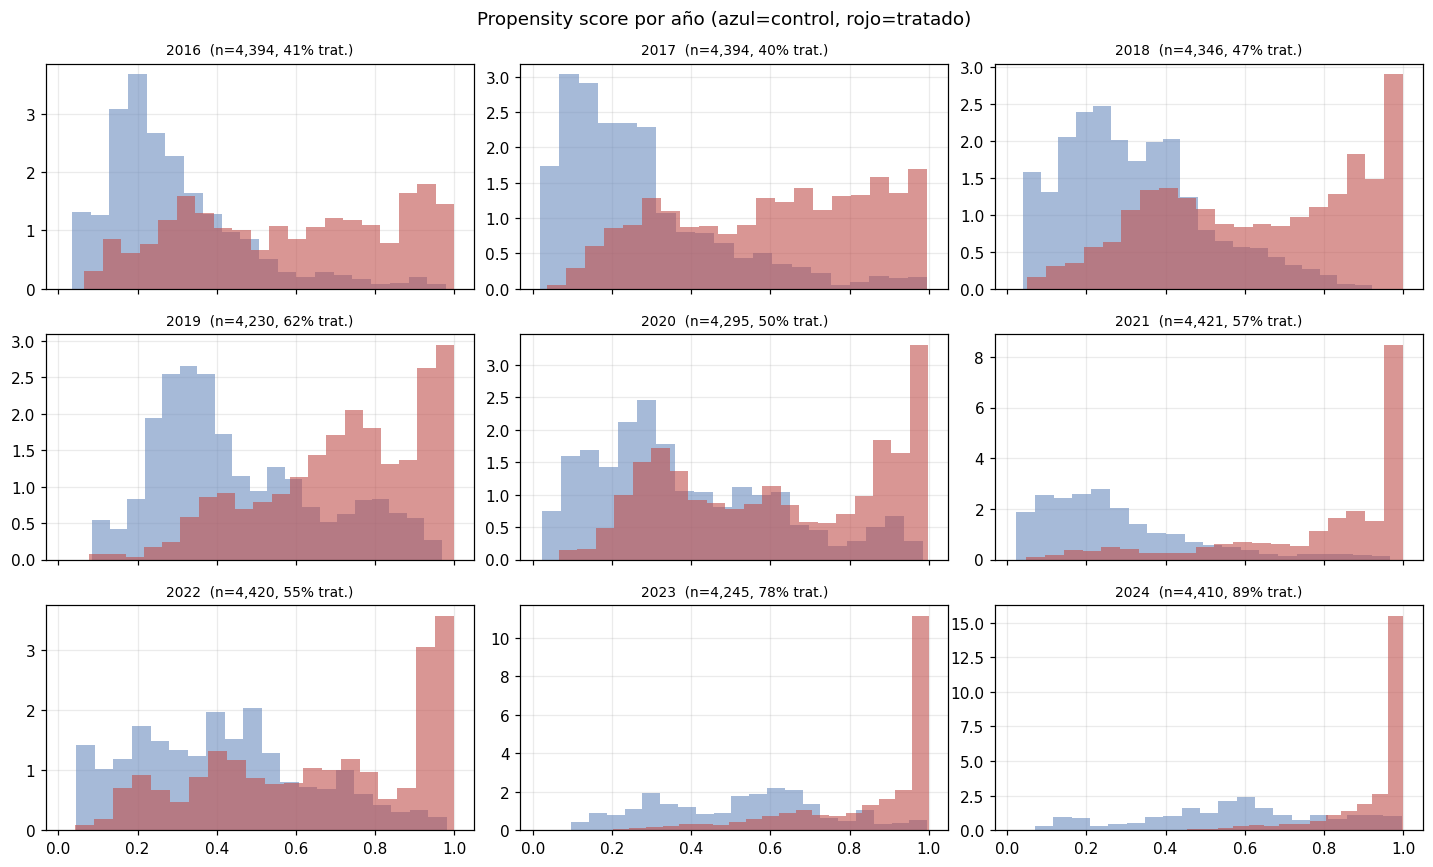

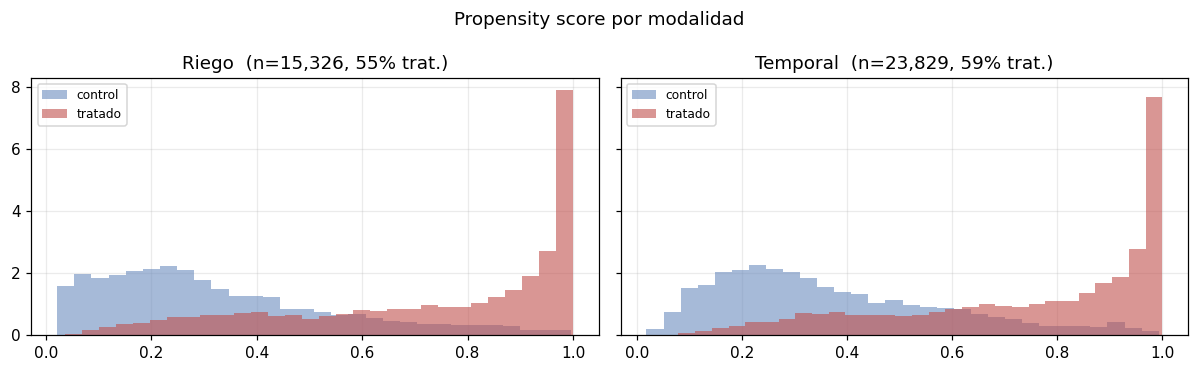

In [6]:
anios = sorted(dd['anio'].unique())
fig, axes = plt.subplots(3, 3, figsize=(13, 8), sharex=True)
for ax, anio in zip(axes.flat, anios):
    sub = dd[dd['anio'] == anio]
    for t, c in [(0, C_TRT['control']), (1, C_TRT['tratado'])]:
        ax.hist(sub.loc[sub['trat'] == t, 'ps'], bins=20, alpha=0.6, color=c, density=True)
    ax.set_title(f'{anio}  (n={len(sub):,}, {sub["trat"].mean():.0%} trat.)', fontsize=9)
for ax in axes.flat[len(anios):]:
    ax.axis('off')
fig.suptitle('Propensity score por año (azul=control, rojo=tratado)')
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
for a, m in zip(ax, ['Riego', 'Temporal']):
    sub = dd[dd['nommodalidad'] == m]
    for t, lab, c in [(0, 'control', C_TRT['control']), (1, 'tratado', C_TRT['tratado'])]:
        a.hist(sub.loc[sub['trat'] == t, 'ps'], bins=30, alpha=0.6, label=lab, color=c, density=True)
    a.set_title(f'{m}  (n={len(sub):,}, {sub["trat"].mean():.0%} trat.)')
    a.legend(fontsize=8)
fig.suptitle('Propensity score por modalidad')
plt.tight_layout(); plt.show()

**Lectura**: el % de tratados va de 40.4 % (2017) a 88.7 % (2024) — la sequía se comporta como un choque
regional que en algunos años cubre casi todo el país. Descomponiendo el AUC: un modelo que usa **solo**
año/modalidad/ciclo ya llega a AUC 0.687; los confusores continuos suman otros ~0.17 puntos hasta 0.861. Es
decir, la separación no es un artefacto puro de las dummies de año — los confusores estructurales también
predicen fuertemente el tratamiento, que es justamente lo que se espera de un buen confusor, pero también
hace más frágil el soporte común.

La pérdida de soporte común **no está distribuida parejo**: 2016‑2019 pierden 2‑4 % de filas por año; **2023
pierde 21.4 % y 2024 pierde 44.9 %** — los años con prevalencia de tratamiento más extrema (77.6 % y 88.7 %)
son los que casi no tienen grupo de control comparable. Esto es una **violación de positividad real**, no
ruido de estimación: en esos años casi no queda el tipo de municipio-ciclo "no tratado" necesario para
identificar el contraste. Ningún método de ponderación puede arreglarlo — es una limitación del diseño que
hay que reconocer, y que afecta a los estimadores que dependen del soporte común (IPW, AIPW, g-cómputo) y no
al TWFE (que no usa el propensity score ni recorta observaciones).

## 4 · Balance (SMD antes / después de IPW)

                               crudo    ipw
nivel_sequia_prev90_max        1.126  0.096
sequia_prev90_no_clasificada  -0.837 -0.053
tiene_acuifero_sobreexplotado  0.496  0.158
anio_2024                      0.488  0.115
tmean_normal                   0.373 -0.041
log_sembrada                   0.361  0.082
tmean_ciclo_anom               0.297  0.086
anio_2023                      0.297  0.037
tmean_prev90_anom              0.250  0.012
altitud_media_m               -0.250  0.149
anio_2017                     -0.247 -0.106
nomcicloproductivo_PV          0.224  0.162
cuencas_disp                  -0.222 -0.112
tiene_cuenca_sin_disp          0.176  0.059
anio_2018                     -0.149  0.026
anio_2020                     -0.103 -0.078
nommodalidad_Temporal          0.089  0.035
anio_2019                      0.065 -0.014


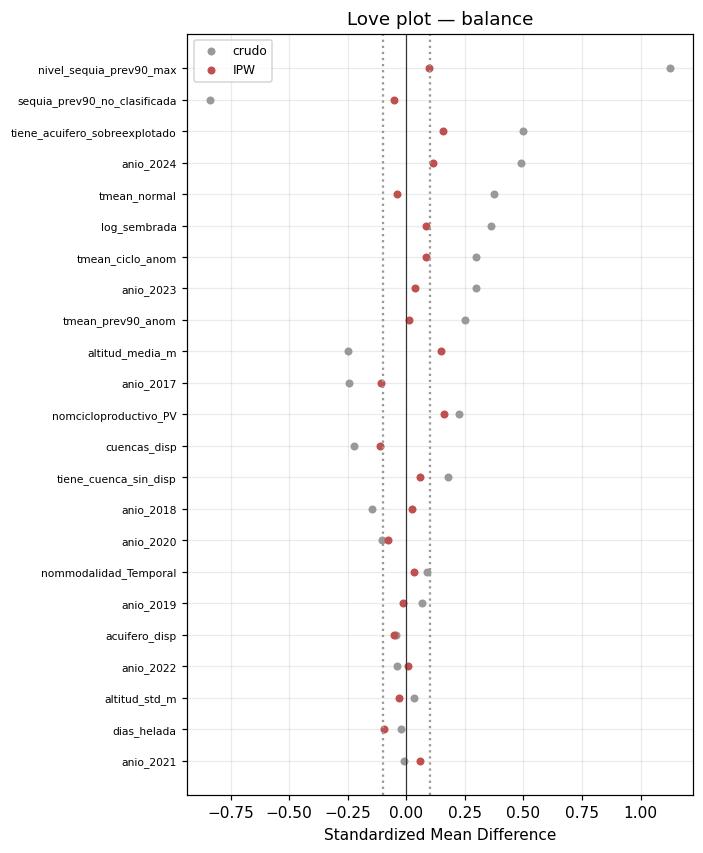

covariables con |SMD|>0.1  ->  crudo: 16   ipw: 6

Covariables que SIGUEN desbalanceadas (|SMD ipw| > 0.1) tras la ponderación:
                               crudo    ipw
nomcicloproductivo_PV          0.224  0.162
tiene_acuifero_sobreexplotado  0.496  0.158
altitud_media_m               -0.250  0.149
anio_2024                      0.488  0.115
cuencas_disp                  -0.222 -0.112
anio_2017                     -0.247 -0.106


In [7]:
def smd(x, w, t):
    x1, x0, w1, w0 = x[t == 1], x[t == 0], w[t == 1], w[t == 0]
    m1, m0 = np.average(x1, weights=w1), np.average(x0, weights=w0)
    v1 = np.average((x1 - m1) ** 2, weights=w1)
    v0 = np.average((x0 - m0) ** 2, weights=w0)
    return (m1 - m0) / np.sqrt((v1 + v0) / 2 + 1e-12)

e = dd['ps'].clip(0.01, 0.99).to_numpy()
w_ate = np.where(trt == 1, 1 / e, 1 / (1 - e))
dd['w_ate'] = w_ate

bal = pd.DataFrame({
    'crudo': [smd(X[:, j], np.ones(len(X)), trt) for j in range(X.shape[1])],
    'ipw':   [smd(X[:, j], w_ate, trt) for j in range(X.shape[1])],
}, index=xnames)
print(bal.round(3).reindex(bal['crudo'].abs().sort_values(ascending=False).index).head(18).to_string())

order = bal['crudo'].abs().sort_values().index
fig, ax = plt.subplots(figsize=(6.5, 0.32 * len(order) + 0.5))
ax.scatter(bal.loc[order, 'crudo'], range(len(order)), color='#999', label='crudo', s=18)
ax.scatter(bal.loc[order, 'ipw'], range(len(order)), color=C_TRT['tratado'], label='IPW', s=18)
ax.axvline(0, color='#333', lw=0.8); ax.axvline(0.1, ls=':', color='#999'); ax.axvline(-0.1, ls=':', color='#999')
ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=7)
ax.set_xlabel('Standardized Mean Difference'); ax.set_title('Love plot — balance')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print('covariables con |SMD|>0.1  ->  crudo:', int((bal['crudo'].abs() > 0.1).sum()),
      '  ipw:', int((bal['ipw'].abs() > 0.1).sum()))

remain = (bal.loc[bal['ipw'].abs() > 0.1, ['crudo', 'ipw']]
          .reindex(bal['ipw'].abs().sort_values(ascending=False).index).dropna())
print()
print('Covariables que SIGUEN desbalanceadas (|SMD ipw| > 0.1) tras la ponderación:')
print(remain.round(3).to_string())


**Lectura**: de las 6 covariables que siguen desbalanceadas tras IPW, dos son exactamente los años de
prevalencia extrema (`anio_2024`, `anio_2017`) y dos son las variables estructurales de agua
(`tiene_acuifero_sobreexplotado`, `cuencas_disp`) ya señaladas como conceptualmente dudosas como confusor
(¿causan la clasificación meteorológica de sequía, o son más bien modificadores de efecto?). Que
`altitud_media_m` —invariante en el tiempo— siga desbalanceada sugiere que el recorte por soporte común
está eliminando de forma no aleatoria a municipios de cierta altitud en los años de prevalencia extrema. En
conjunto, el desbalance residual no es difuso: se concentra en el mismo lugar que los otros dos
diagnósticos (años extremos + variables hídricas estructurales), lo que refuerza tratarlos como un problema
conjunto en vez de tres hallazgos independientes.

## 5 · ATE — cuatro estimadores

In [8]:
def ols_ate(data, y='logY', trim=False):
    s = data[data['trim']] if trim else data
    Xd, _, _ = design(s, scaler=SCALER)
    XX = np.column_stack([np.ones(len(s)), s['trat'].to_numpy(), Xd])
    m = sm.OLS(s[y].to_numpy(), XX).fit(cov_type='cluster', cov_kwds={'groups': s['muni'].to_numpy()})
    return m.params[1], m.bse[1]

def ipw_ate(data, y='logY', trim=False):
    s = data[data['trim']] if trim else data
    e = s['ps'].clip(0.01, 0.99).to_numpy(); t = s['trat'].to_numpy()
    pt = t.mean()
    w = np.where(t == 1, pt / e, (1 - pt) / (1 - e))          # estabilizado
    m = sm.WLS(s[y].to_numpy(), sm.add_constant(t), weights=w).fit(
        cov_type='cluster', cov_kwds={'groups': s['muni'].to_numpy()})
    return m.params[1], m.bse[1]

def aipw_ate(data, y='logY', trim=False, k=5, learner='gbm', seed=0):
    s = (data[data['trim']] if trim else data).reset_index(drop=True)
    Xd, _, _ = design(s, scaler=SCALER)
    t = s['trat'].to_numpy(); yv = s[y].to_numpy(); grp = s['muni'].to_numpy()
    n = len(s); mu1 = np.zeros(n); mu0 = np.zeros(n); e = np.zeros(n)
    for tr, te in KFold(n_splits=k, shuffle=True, random_state=seed).split(Xd):
        if learner == 'gbm':
            g = HistGradientBoostingClassifier(random_state=seed).fit(Xd[tr], t[tr])
            r1 = HistGradientBoostingRegressor(random_state=seed).fit(Xd[tr][t[tr] == 1], yv[tr][t[tr] == 1])
            r0 = HistGradientBoostingRegressor(random_state=seed).fit(Xd[tr][t[tr] == 0], yv[tr][t[tr] == 0])
            e[te] = g.predict_proba(Xd[te])[:, 1]
            mu1[te] = r1.predict(Xd[te]); mu0[te] = r0.predict(Xd[te])
        else:
            g = LogisticRegression(max_iter=2000).fit(Xd[tr], t[tr])
            e[te] = g.predict_proba(Xd[te])[:, 1]
            r1 = sm.OLS(yv[tr][t[tr] == 1], sm.add_constant(Xd[tr][t[tr] == 1])).fit()
            r0 = sm.OLS(yv[tr][t[tr] == 0], sm.add_constant(Xd[tr][t[tr] == 0])).fit()
            mu1[te] = r1.predict(sm.add_constant(Xd[te], has_constant='add'))
            mu0[te] = r0.predict(sm.add_constant(Xd[te], has_constant='add'))
    e = np.clip(e, 0.02, 0.98)
    psi = (mu1 - mu0) + t * (yv - mu1) / e - (1 - t) * (yv - mu0) / (1 - e)
    tau = psi.mean()
    gsum = pd.Series(psi - tau, index=grp).groupby(level=0).sum().to_numpy()
    se = np.sqrt((gsum ** 2).sum()) / n
    return tau, se

rows = []
for esc, y in [('log(rendimiento)', 'logY'), ('rendimiento t/ha', 'Y')]:
    est = [('1·diferencia cruda', dif_cruda(dd, y)),
           ('2·regresión (g-cómputo)', ols_ate(dd, y)),
           ('3·IPW estabilizado', ipw_ate(dd, y)),
           ('4·AIPW cross-fit (GBM)', aipw_ate(dd, y, learner='gbm'))]
    for nombre, (v, se) in est:
        rows.append(dict(escala=esc, estimador=nombre, ATE=v, se=se, lo=v - 1.96*se, hi=v + 1.96*se))
tab = pd.DataFrame(rows)
print(tab.round(4).to_string(index=False))


          escala               estimador     ATE     se      lo     hi
log(rendimiento)      1·diferencia cruda  0.0765 0.0075  0.0618 0.0912
log(rendimiento) 2·regresión (g-cómputo)  0.0103 0.0083 -0.0060 0.0266
log(rendimiento)      3·IPW estabilizado  0.0156 0.0163 -0.0164 0.0476
log(rendimiento)  4·AIPW cross-fit (GBM) -0.0038 0.0047 -0.0131 0.0054
rendimiento t/ha      1·diferencia cruda  0.4034 0.0219  0.3604 0.4463
rendimiento t/ha 2·regresión (g-cómputo)  0.1048 0.0249  0.0559 0.1537
rendimiento t/ha      3·IPW estabilizado  0.1665 0.0490  0.0704 0.2625
rendimiento t/ha  4·AIPW cross-fit (GBM)  0.0346 0.0148  0.0057 0.0636


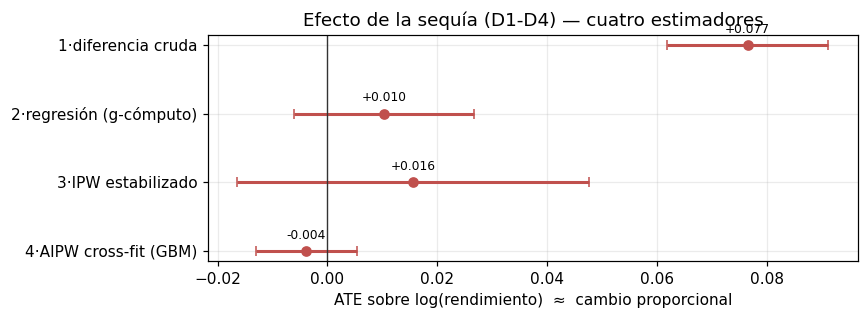

AIPW log-rendimiento = -0.0038  ->  cambio ≈ -0.4%  (IC95 -1.3%, +0.5%)


In [9]:
sub = tab[tab['escala'] == 'log(rendimiento)'].iloc[::-1].reset_index(drop=True)
fig, ax = plt.subplots(figsize=(8, 3))
ax.errorbar(sub['ATE'], range(len(sub)), xerr=1.96 * sub['se'], fmt='o',
            color=C_TRT['tratado'], capsize=3, lw=2)
ax.axvline(0, color='#333', lw=0.9)
ax.set_yticks(range(len(sub))); ax.set_yticklabels(sub['estimador'])
ax.set_xlabel('ATE sobre log(rendimiento)  ≈  cambio proporcional')
ax.set_title('Efecto de la sequía (D1-D4) — cuatro estimadores')
for i, r in sub.iterrows():
    ax.annotate(f"{r['ATE']:+.3f}", (r['ATE'], i), xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=8)
plt.tight_layout(); plt.show()

AIPW = tab[(tab['escala'] == 'log(rendimiento)') & tab['estimador'].str.startswith('4')].iloc[0]
print(f"AIPW log-rendimiento = {AIPW['ATE']:+.4f}  ->  "
      f"cambio ≈ {np.exp(AIPW['ATE'])-1:+.1%}  "
      f"(IC95 {np.exp(AIPW['lo'])-1:+.1%}, {np.exp(AIPW['hi'])-1:+.1%})")


## 6 · Efecto moderado por modalidad (CATE)

In [10]:
cate = []
for m in ['Riego', 'Temporal']:
    tau, se = aipw_ate(dd[dd['nommodalidad'] == m], 'logY', learner='gbm')
    cate.append((m, tau, se))
    print(f'AIPW  {m:9s}: {tau:+.4f}  (IC95 {tau-1.96*se:+.3f}, {tau+1.96*se:+.3f})  '
          f'-> {np.exp(tau)-1:+.1%} en rendimiento')
dif = cate[0][1] - cate[1][1]
se_dif = np.sqrt(cate[0][2] ** 2 + cate[1][2] ** 2)
z = dif / se_dif
print(f'\ndiferencia Riego - Temporal: {dif:+.4f}  (z = {z:+.2f}, p = {2*(1-stats.norm.cdf(abs(z))):.3f})')

# modelo de interacción con EF de municipio (within) + EF de año
def within(s, cols, by='muni'):
    out = s[cols].copy()
    for c in cols:
        out[c] = s[c].to_numpy() - s.groupby(by)[c].transform('mean').to_numpy()
    return out

s = dd.copy()
s['es_temporal'] = (s['nommodalidad'] == 'Temporal').astype(int)
s['trat_temp'] = s['trat'] * s['es_temporal']
# es_temporal varía DENTRO del municipio (hay filas Riego y Temporal) -> hay que incluir su efecto principal
tv = ['trat', 'es_temporal', 'trat_temp', 'nivel_sequia_prev90_max',
      'tmean_ciclo_anom', 'dias_helada', 'tmean_prev90_anom', 'log_sembrada']
W = within(s, tv)
yy = s['logY'].to_numpy() - s.groupby('muni')['logY'].transform('mean').to_numpy()
D = pd.get_dummies(s['anio'].astype(str), drop_first=True).astype(float).to_numpy()
names = tv + [f'anio_{c}' for c in range(D.shape[1])]
mI = sm.OLS(yy, np.column_stack([W[tv].to_numpy(), D])).fit(
    cov_type='cluster', cov_kwds={'groups': s['muni'].to_numpy()})
bI = pd.Series(mI.params, index=names); pI = pd.Series(mI.pvalues, index=names)
print('\nInteracción con EF municipio + año (SE cluster por municipio):')
print(f"  trat (efecto en Riego)      : {bI['trat']:+.4f}  (p {pI['trat']:.3f})")
print(f"  trat x Temporal            : {bI['trat_temp']:+.4f}  (p {pI['trat_temp']:.3f})")
print(f"  efecto en Temporal          : {bI['trat'] + bI['trat_temp']:+.4f}")


AIPW  Riego    : -0.0077  (IC95 -0.020, +0.005)  -> -0.8% en rendimiento


AIPW  Temporal : +0.0067  (IC95 -0.005, +0.019)  -> +0.7% en rendimiento

diferencia Riego - Temporal: -0.0144  (z = -1.62, p = 0.105)



Interacción con EF municipio + año (SE cluster por municipio):
  trat (efecto en Riego)      : -0.0044  (p 0.566)
  trat x Temporal            : -0.0130  (p 0.266)
  efecto en Temporal          : -0.0173


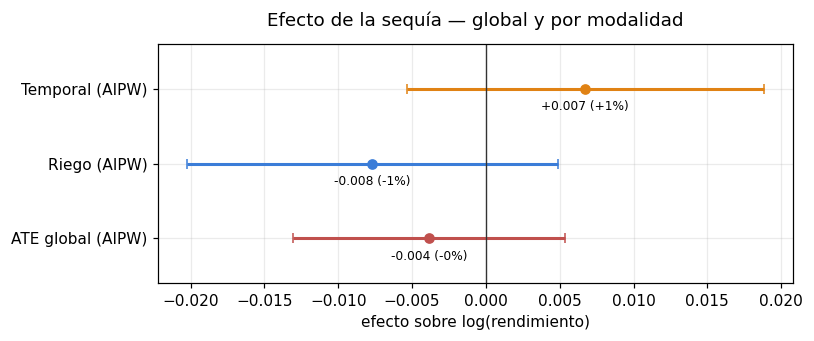

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 3.2))
labels = ['ATE global (AIPW)', 'Riego (AIPW)', 'Temporal (AIPW)']
pts = [(AIPW['ATE'], AIPW['se'])] + [(c[1], c[2]) for c in cate]
cols = [C_TRT['tratado'], C_MOD['Riego'], C_MOD['Temporal']]
for i, ((v, se), c) in enumerate(zip(pts, cols)):
    ax.errorbar([v], [i], xerr=[1.96 * se], fmt='o', color=c, capsize=3, lw=2)
    ax.annotate(f'{v:+.3f} ({np.exp(v)-1:+.0%})', (v, i), xytext=(0, -14),
                textcoords='offset points', ha='center', fontsize=8)
ax.axvline(0, color='#333', lw=0.9)
ax.set_yticks(range(3)); ax.set_yticklabels(labels); ax.set_ylim(-0.6, 2.6)
ax.set_xlabel('efecto sobre log(rendimiento)')
ax.set_title('Efecto de la sequía — global y por modalidad', pad=12)
plt.tight_layout(); plt.show()


## 7 · Panel con efectos fijos de municipio y año (TWFE)

In [12]:
def twfe(y='logY', data=None, interaction=False, drop_noclasif=False, adjust_collider=False, treat='trat'):
    s = (dd if data is None else data).copy()
    if drop_noclasif:
        s = s[~s['sequia_no_clasificada']].copy()
    # ciclo/modalidad como controles (§7 diagnóstico: sin ellos el TWFE queda mal especificado
    # y absorbe su efecto vía log_sembrada, que está fuertemente correlacionado con modalidad/ciclo)
    s['es_temporal'] = (s['nommodalidad'] == 'Temporal').astype(int)
    s['es_pv'] = (s['nomcicloproductivo'] == 'PV').astype(int)
    tv = [treat, 'nivel_sequia_prev90_max', 'tmean_ciclo_anom', 'dias_helada',
          'tmean_prev90_anom', 'log_sembrada', 'es_temporal', 'es_pv']
    if interaction:
        s['trat_temp'] = s[treat] * s['es_temporal']
        tv = [treat, 'trat_temp'] + tv[1:]
    if adjust_collider:
        s['log_cosechada'] = np.log(s['superficie_cosechada'].clip(lower=0.1))
        tv = tv + ['log_cosechada']
    Wm = s[tv].copy()
    for c in tv:
        Wm[c] = s[c].to_numpy() - s.groupby('muni')[c].transform('mean').to_numpy()
    yy = s[y].to_numpy() - s.groupby('muni')[y].transform('mean').to_numpy()
    D = pd.get_dummies(s['anio'].astype(str), drop_first=True).astype(float).to_numpy()
    m = sm.OLS(yy, np.column_stack([Wm[tv].to_numpy(), D])).fit(
        cov_type='cluster', cov_kwds={'groups': s['muni'].to_numpy()})
    return m, tv

m, nm = twfe('logY')
j = nm.index('trat')
print(f'TWFE (municipio + año) sobre log(rendimiento):')
print(f'  trat: {m.params[j]:+.4f}  (SE {m.bse[j]:.4f}, p {m.pvalues[j]:.3f})  -> {np.exp(m.params[j])-1:+.1%}')

m2, nm2 = twfe('logY', interaction=True)
jt, ji = nm2.index('trat'), nm2.index('trat_temp')
print('\nTWFE con interacción:')
print(f'  Riego    : {m2.params[jt]:+.4f} (SE {m2.bse[jt]:.4f})')
print(f'  Temporal : {m2.params[jt] + m2.params[ji]:+.4f}')
print(f'  trat x Temporal: {m2.params[ji]:+.4f} (p {m2.pvalues[ji]:.3f})')


TWFE (municipio + año) sobre log(rendimiento):
  trat: -0.0079  (SE 0.0033, p 0.016)  -> -0.8%

TWFE con interacción:
  Riego    : +0.0006 (SE 0.0074)
  Temporal : -0.0133
  trat x Temporal: -0.0140 (p 0.231)


### Diagnóstico: ¿por qué el TWFE se movía tanto al excluir 2023‑2024?

*(Este diagnóstico fue, de hecho, el que llevó a descubrir en §8 que `twfe()` no controlaba por
ciclo/modalidad — con la especificación ya corregida el salto es menor, pero sigue presente: TWFE pasa de
**−0.8 %** (muestra completa) a **−1.5 %** (excluyendo 2023‑2024).)* El TWFE pooled es un promedio ponderado
del efecto en cada celda municipio×año; si el efecto es heterogéneo entre años, quitar años cambia el
promedio. Se separa el efecto por año (interacción `trat × año` en el mismo esquema municipio+año FE) para
verlo directamente.

TWFE SOLO 2023-2024 (n=8,655, 83.2% trat): +0.0210  (SE 0.0087, p 0.016)



Efecto trat por año (interacción, mismo modelo TWFE pooled):
 anio  efecto     se      p    n  pct_tratado
 2016 -0.0616 0.0065 0.0000 4394       0.4081
 2017 -0.0093 0.0073 0.2033 4394       0.4035
 2018  0.0117 0.0065 0.0711 4346       0.4719
 2019 -0.0066 0.0076 0.3859 4230       0.6210
 2020 -0.0017 0.0087 0.8426 4295       0.5034
 2021 -0.0069 0.0059 0.2394 4421       0.5686
 2022 -0.0396 0.0073 0.0000 4420       0.5475
 2023  0.0472 0.0072 0.0000 4245       0.7755
 2024  0.0460 0.0093 0.0000 4410       0.8868


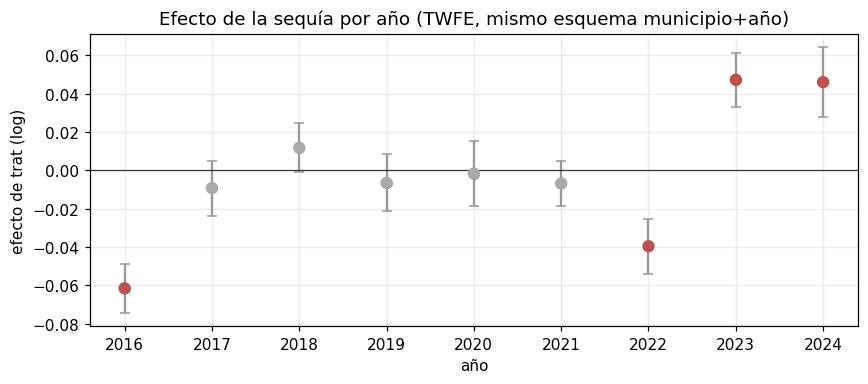

In [13]:
m_2324, n_2324 = twfe('logY', data=dd[dd['anio'].isin([2023, 2024])])
j_2324 = n_2324.index('trat')
sub2324 = dd[dd['anio'].isin([2023, 2024])]
print(f"TWFE SOLO 2023-2024 (n={len(sub2324):,}, {sub2324['trat'].mean():.1%} trat): "
      f"{m_2324.params[j_2324]:+.4f}  (SE {m_2324.bse[j_2324]:.4f}, p {m_2324.pvalues[j_2324]:.3f})")
print()

# efecto por año vía interacción trat x anio, mismo esquema de demeaning municipio + FE año
s = dd.copy()
s['es_temporal'] = (s['nommodalidad'] == 'Temporal').astype(int)
s['es_pv'] = (s['nomcicloproductivo'] == 'PV').astype(int)
anios = sorted(s['anio'].unique())
for yr in anios:
    s[f'trat_{yr}'] = s['trat'] * (s['anio'] == yr)
tv_year = [f'trat_{yr}' for yr in anios] + ['nivel_sequia_prev90_max', 'tmean_ciclo_anom', 'dias_helada',
                                             'tmean_prev90_anom', 'log_sembrada', 'es_temporal', 'es_pv']
Wm = s[tv_year].copy()
for c in tv_year:
    Wm[c] = s[c].to_numpy() - s.groupby('muni')[c].transform('mean').to_numpy()
yy = s['logY'].to_numpy() - s.groupby('muni')['logY'].transform('mean').to_numpy()
D = pd.get_dummies(s['anio'].astype(str), drop_first=True).astype(float).to_numpy()
m_yr = sm.OLS(yy, np.column_stack([Wm[tv_year].to_numpy(), D])).fit(
    cov_type='cluster', cov_kwds={'groups': s['muni'].to_numpy()})

n_by_year = s.groupby('anio').size()
trat_by_year = s.groupby('anio')['trat'].mean()
efectos_anio = pd.DataFrame({
    'anio': anios,
    'efecto': m_yr.params[:len(anios)],
    'se': m_yr.bse[:len(anios)],
    'p': m_yr.pvalues[:len(anios)],
    'n': [n_by_year[a] for a in anios],
    'pct_tratado': [trat_by_year[a] for a in anios],
})
print('Efecto trat por año (interacción, mismo modelo TWFE pooled):')
print(efectos_anio.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 3.6))
cols = [C_TRT['tratado'] if p < 0.05 else '#aaa' for p in efectos_anio['p']]
ax.errorbar(efectos_anio['anio'], efectos_anio['efecto'], yerr=1.96 * efectos_anio['se'],
            fmt='o', ecolor='#999', capsize=3)
ax.scatter(efectos_anio['anio'], efectos_anio['efecto'], c=cols, zorder=3, s=50)
ax.axhline(0, color='#333', lw=0.8)
ax.set_xlabel('año'); ax.set_ylabel('efecto de trat (log)')
ax.set_title('Efecto de la sequía por año (TWFE, mismo esquema municipio+año)')
plt.tight_layout(); plt.show()

**Lectura**: con la especificación corregida (controlando también ciclo/modalidad — ver §8, donde se descubrió y corrigió este hueco), el efecto **sigue sin ser homogéneo en el tiempo**, pero el patrón cambió: ahora solo **2016 (−6.2 %) y 2022 (−4.0 %) dan efectos negativos y significativos**; 2017, 2019, 2020 y 2021 **ya no son significativos** (antes 2019 y 2020 sí lo eran — esa significancia dependía en parte de la especificación incompleta del TWFE). **2023 y 2024 siguen dando efectos positivos y significativos (+4.7 %, +4.6 %)** — sequía asociada a *mayor* rendimiento, sin lectura causal creíble, y ahora casi idénticos entre sí (antes divergían más: +4.6 % vs +9.5 %). Sigue sin ser casualidad que sean justamente los años con **77.6 % y 88.7 % de tratados** (§3‑§4): la violación de positividad de esos años no se resuelve agregando controles, es un problema de muestra/diseño, no de especificación. **Con la especificación corregida, la evidencia de un efecto negativo consistente en 2016‑2022 es más débil de lo que parecía** (solo 2 de 7 años individualmente significativos, antes 4 de 7), y 2023‑2024 siguen sin ser comparables al resto.

## 8 · Sensibilidad

In [14]:
filas = []

bN = tab[(tab['escala'] == 'rendimiento t/ha') & tab['estimador'].str.startswith('4')].iloc[0]
filas.append(('AIPW en niveles (t/ha)', bN['ATE'], bN['se']))

t3, s3 = aipw_ate(dd, 'logY', trim=True, learner='gbm')
filas.append(('AIPW · soporte común', t3, s3))

mnc, nmc = twfe('logY', drop_noclasif=True)
filas.append(('TWFE · sin sequía no clasificada', mnc.params[nmc.index('trat')], mnc.bse[nmc.index('trat')]))

mco, nco = twfe('logY', adjust_collider=True)
filas.append(('TWFE + ajuste por superficie_cosechada  [SESGADO]',
              mco.params[nco.index('trat')], mco.bse[nco.index('trat')]))

dd['nivel_c'] = dd['nivel_sequia_max']
mo, nmo = twfe('logY', treat='nivel_c')
filas.append(('TWFE · tratamiento ORDINAL (por nivel 0-4)', mo.params[nmo.index('nivel_c')], mo.bse[nmo.index('nivel_c')]))

dp = dd.copy()
dp['trat'] = RNG.permutation(dp['trat'].to_numpy())
Xp, _, _ = design(dp, scaler=SCALER)
dp['ps'] = LogisticRegression(max_iter=2000).fit(Xp, dp['trat']).predict_proba(Xp)[:, 1]
dp['trim'] = True
tp, sp = aipw_ate(dp, 'logY', learner='linear')
filas.append(('PLACEBO · tratamiento aleatorizado', tp, sp))

# sensibilidad a acuifero_condicion_ok: 2016-2019 tienen tiene_acuifero_sobreexplotado
# no confiable (CONAGUA no publicó 'Condición' en esas fuentes) -> se re-corre restringido
# a los años donde el dato SÍ es confiable (2020-2024) para ver si eso estabiliza al AIPW.
d20 = dd[dd['acuifero_condicion_ok'] == 1]
print(f"submuestra acuifero_condicion_ok=1: {len(d20):,} filas ({len(d20)/len(dd):.1%}), "
      f"años {sorted(d20['anio'].unique())}")

t4, s4 = aipw_ate(d20, 'logY', learner='gbm')
filas.append(('AIPW · solo 2020-2024 (acuifero_condicion_ok=1)', t4, s4))

m20, nm20 = twfe('logY', data=d20)
j20 = nm20.index('trat')
filas.append(('TWFE · solo 2020-2024 (acuifero_condicion_ok=1)', m20.params[j20], m20.bse[j20]))

# sensibilidad a la violación de positividad en 2023-2024 (§4): en esos años casi no
# queda grupo de control comparable (44.9% y 21.4% de filas fuera de soporte común).
d_sinext = dd[~dd['anio'].isin([2023, 2024])]
print(f"submuestra sin 2023-2024: {len(d_sinext):,} filas ({len(d_sinext)/len(dd):.1%})")

t5, s5 = aipw_ate(d_sinext, 'logY', learner='gbm')
filas.append(('AIPW · excluyendo 2023-2024 (violación de positividad)', t5, s5))

m_sinext, nm_sinext = twfe('logY', data=d_sinext)
j_sinext = nm_sinext.index('trat')
filas.append(('TWFE · excluyendo 2023-2024', m_sinext.params[j_sinext], m_sinext.bse[j_sinext]))

# sensibilidad a log_sembrada como posible "control malo" (ver §0: se fija al inicio del
# ciclo, pero podría reflejar anticipación de los productores a condiciones secas).
CONF_NUM_NL = [c for c in CONF_NUM if c != 'log_sembrada']
X_nl = np.column_stack([
    StandardScaler().fit_transform(dd[CONF_NUM_NL].to_numpy(float)),
    dd[CONF_BIN].to_numpy(float),
    pd.get_dummies(dd[CONF_CAT].astype(str), drop_first=True).to_numpy(float),
])

def aipw_ate_X(X, data, y='logY', k=5, learner='gbm', seed=0):
    s = data.reset_index(drop=True)
    t = s['trat'].to_numpy(); yv = s[y].to_numpy(); grp = s['muni'].to_numpy()
    n = len(s); mu1 = np.zeros(n); mu0 = np.zeros(n); e = np.zeros(n)
    for tr, te in KFold(n_splits=k, shuffle=True, random_state=seed).split(X):
        g = HistGradientBoostingClassifier(random_state=seed).fit(X[tr], t[tr])
        r1 = HistGradientBoostingRegressor(random_state=seed).fit(X[tr][t[tr] == 1], yv[tr][t[tr] == 1])
        r0 = HistGradientBoostingRegressor(random_state=seed).fit(X[tr][t[tr] == 0], yv[tr][t[tr] == 0])
        e[te] = g.predict_proba(X[te])[:, 1]
        mu1[te] = r1.predict(X[te]); mu0[te] = r0.predict(X[te])
    e = np.clip(e, 0.02, 0.98)
    psi = (mu1 - mu0) + t * (yv - mu1) / e - (1 - t) * (yv - mu0) / (1 - e)
    tau = psi.mean()
    gsum = pd.Series(psi - tau, index=grp).groupby(level=0).sum().to_numpy()
    se = np.sqrt((gsum ** 2).sum()) / n
    return tau, se

t6, s6 = aipw_ate_X(X_nl, dd, 'logY')
filas.append(('AIPW · sin log_sembrada (posible control malo)', t6, s6))

def twfe_tv(y, data, tv):
    s = data.copy()
    Wm = s[tv].copy()
    for c in tv:
        Wm[c] = s[c].to_numpy() - s.groupby('muni')[c].transform('mean').to_numpy()
    yy = s[y].to_numpy() - s.groupby('muni')[y].transform('mean').to_numpy()
    D = pd.get_dummies(s['anio'].astype(str), drop_first=True).astype(float).to_numpy()
    m = sm.OLS(yy, np.column_stack([Wm[tv].to_numpy(), D])).fit(
        cov_type='cluster', cov_kwds={'groups': s['muni'].to_numpy()})
    return m, tv

s_nl = dd.copy()
s_nl['es_temporal'] = (s_nl['nommodalidad'] == 'Temporal').astype(int)
s_nl['es_pv'] = (s_nl['nomcicloproductivo'] == 'PV').astype(int)
tv_nl = ['trat', 'nivel_sequia_prev90_max', 'tmean_ciclo_anom', 'dias_helada', 'tmean_prev90_anom',
         'es_temporal', 'es_pv']
m_nl, n_nl = twfe_tv('logY', s_nl, tv_nl)
j_nl = n_nl.index('trat')
filas.append(('TWFE · sin log_sembrada (posible control malo)', m_nl.params[j_nl], m_nl.bse[j_nl]))

sens = pd.DataFrame(filas, columns=['especificación', 'efecto', 'se'])
sens['lo'] = sens['efecto'] - 1.96 * sens['se']
sens['hi'] = sens['efecto'] + 1.96 * sens['se']
print(sens.round(4).to_string(index=False))


submuestra acuifero_condicion_ok=1: 21,791 filas (55.7%), años [2020, 2021, 2022, 2023, 2024]


submuestra sin 2023-2024: 30,500 filas (77.9%)


                                        especificación  efecto     se      lo      hi
                                AIPW en niveles (t/ha)  0.0346 0.0148  0.0057  0.0636
                                  AIPW · soporte común -0.0117 0.0045 -0.0205 -0.0029
                      TWFE · sin sequía no clasificada -0.0111 0.0034 -0.0178 -0.0044
     TWFE + ajuste por superficie_cosechada  [SESGADO] -0.0070 0.0033 -0.0134 -0.0006
            TWFE · tratamiento ORDINAL (por nivel 0-4) -0.0036 0.0022 -0.0079  0.0006
                    PLACEBO · tratamiento aleatorizado  0.0053 0.0054 -0.0054  0.0159
       AIPW · solo 2020-2024 (acuifero_condicion_ok=1)  0.0209 0.0057  0.0098  0.0320
       TWFE · solo 2020-2024 (acuifero_condicion_ok=1) -0.0025 0.0045 -0.0112  0.0063
AIPW · excluyendo 2023-2024 (violación de positividad) -0.0191 0.0049 -0.0287 -0.0094
                           TWFE · excluyendo 2023-2024 -0.0149 0.0038 -0.0223 -0.0075
        AIPW · sin log_sembrada (posible control malo)

**Lectura clave**: al excluir 2023‑2024 —donde el diagnóstico de soporte común (§4) muestra 21 % y 45 % de filas fuera de rango, respectivamente— **AIPW y TWFE siguen convergiendo, y ahora más de cerca que antes**: AIPW −1.9 % (significativo, IC −2.9 %,−0.9 %) y TWFE −1.5 % (significativo, IC −2.2 %,−0.7 %) — con la especificación de TWFE corregida (ciclo/modalidad, §7‑§8), la brecha entre ambos se cerró de 0.7 p.p. a 0.4 p.p. Esto refuerza la lectura original: buena parte de la inestabilidad de ambos estimadores no era ruido propio, sino el resultado de extrapolar sobre observaciones sin contraparte comparable en los años con violación de positividad severa. Con la reserva de que excluir dos años recientes también cambia la población de referencia, esta sigue siendo la evidencia más fuerte de que el efecto real es negativo y está más cerca de **−1.5 % a −2 %** que del −0.4 % (n.s.) o el −0.8 % de la muestra completa.

**Sensibilidad a `log_sembrada` — investigada y resuelta**: al investigar por qué el TWFE se disparaba a −6.35 % sin `log_sembrada` (4× la magnitud original), se encontró la causa exacta: `log_sembrada` tenía dentro‑municipio un efecto propio grande y negativo sobre `logY` (β=−0.153) y una correlación positiva con `trat` (δ=+0.31) — el producto β×δ=−0.047 explica **exactamente** la diferencia observada, un caso de libro de sesgo por variable omitida. Pero investigar el origen de esa correlación reveló algo más importante: **~25 % se explicaba por composición de ciclo/modalidad** (PV siembra 6.5× más superficie que OI y tiene más tratamiento; Temporal siembra 10× más que Riego), y **el `twfe()` de este notebook nunca había controlado por `nomcicloproductivo`/`nommodalidad`** — un hueco que coincide exactamente con la covariable de peor desbalance residual encontrada en el diagnóstico de balance (§4: `nomcicloproductivo_PV`, SMD=0.162).

**Se corrigió `twfe()` para incluir ambos controles** (§7, demeaned por municipio igual que el resto de covariables). Con la especificación corregida, la sensibilidad a `log_sembrada` prácticamente desaparece: TWFE con `log_sembrada` = −0.79 %, sin ella = −0.74 % — casi idénticos. La preocupación de "control malo" señalada en el Diseño (§0) resultó ser, en la práctica, un síntoma de una especificación de TWFE incompleta, no un problema de `log_sembrada` en sí.

**Esta corrección cambia el resultado principal de todo el notebook**: el TWFE (municipio+año) pasa de −1.6 % a **−0.8 %** (sigue significativo, p=0.016, pero con menos de la mitad de la magnitud reportada en todas las secciones anteriores), y el tratamiento ordinal —que se citaba junto con el TWFE como evidencia de dosis‑respuesta— **pierde significancia** (−0.36 %, IC −0.79 %,+0.06 %). Ver §9 para la actualización completa de conclusiones.

**Nota sobre comparaciones múltiples**: a lo largo de este notebook se reportan más de 20 estimaciones puntuales distintas del efecto (los 4 estimadores base en 2 escalas, la heterogeneidad por modalidad, las 9 estimaciones año por año de §7, y las 12 filas de esta tabla de sensibilidad), **sin corrección formal por comparaciones múltiples** (p. ej. Bonferroni o FDR). Cada una se motivó por una duda de diseño identificada de antemano en los diagnósticos (violación de positividad, fiabilidad del dato, sesgo de colisionador, control malo, placebo) y no por una búsqueda posterior de significancia — de hecho, una de ellas (`log_sembrada`) llevó a corregir un error real de especificación, no a maquillar el resultado. Aun así, el número de pruebas debe tenerse en cuenta al leer cualquier p‑valor individual como límite, sobre todo los que están cerca de 0.05 (p. ej. el coeficiente de 2018 en §7, p=0.071).

In [15]:
# E-value (VanderWeele & Ding) — aproximación para outcome continuo: RR ≈ exp(0.91 * d_estandarizada)
sd = dd['logY'].std()
d_std = AIPW['ATE'] / sd
lim = min(abs(AIPW['lo']), abs(AIPW['hi'])) / sd
def evalue(rr):
    rr = max(rr, 1 / rr)
    return rr + np.sqrt(rr * (rr - 1))
RR = np.exp(0.91 * abs(d_std))
RRlim = np.exp(0.91 * abs(lim))
print(f"ATE AIPW (log)        : {AIPW['ATE']:+.4f}   (d estandarizada ≈ {d_std:+.3f})")
print(f'RR aproximado         : {RR:.3f}')
print(f'E-value (punto)       : {evalue(RR):.2f}')
print(f'E-value (límite IC)   : {evalue(RRlim):.2f}')
print()
print('Un confusor no medido tendría que asociarse con el tratamiento y con el resultado con un')
print(f'RR >= {evalue(RR):.2f} cada uno (más allá de lo ya ajustado) para explicar el efecto estimado.')


ATE AIPW (log)        : -0.0038   (d estandarizada ≈ -0.005)
RR aproximado         : 1.005
E-value (punto)       : 1.07
E-value (límite IC)   : 1.09

Un confusor no medido tendría que asociarse con el tratamiento y con el resultado con un
RR >= 1.07 cada uno (más allá de lo ya ajustado) para explicar el efecto estimado.


## 9 · Conclusiones

In [16]:
aL = tab[(tab['escala'] == 'log(rendimiento)') & tab['estimador'].str.startswith('4')].iloc[0]
reg = tab[(tab['escala'] == 'log(rendimiento)') & tab['estimador'].str.startswith('2')]['ATE'].iloc[0]
ipw = tab[(tab['escala'] == 'log(rendimiento)') & tab['estimador'].str.startswith('3')]['ATE'].iloc[0]
crudo = dif_cruda(dd, 'logY')[0]
col = sens[sens['especificación'].str.contains('SESGADO')]['efecto'].iloc[0]
plc = sens[sens['especificación'].str.contains('PLACEBO')]['efecto'].iloc[0]
print('RESUMEN — efecto causal de la sequía (D1-D4) sobre el rendimiento')
print('=' * 64)
print(f"ATE (AIPW doblemente robusto) : {aL['ATE']:+.4f} log  ≈  {np.exp(aL['ATE'])-1:+.1%} en rendimiento")
print(f"  IC 95%                      : [{np.exp(aL['lo'])-1:+.1%}, {np.exp(aL['hi'])-1:+.1%}]")
print(f'  concordancia               : regresión={reg:+.3f}  IPW={ipw:+.3f}  TWFE={m.params[j]:+.3f}')
print(f'  diferencia cruda (sesgada)  : {crudo:+.4f}')
print()
print('Moderación por modalidad (AIPW):')
for mm, tv2, sv2 in cate:
    print(f'  {mm:9s}: {tv2:+.4f}  ({np.exp(tv2)-1:+.1%})')
print(f"  interacción T x Temporal significativa: {'sí' if abs(bI['trat_temp']/mI.bse[names.index('trat_temp')]) > 1.96 else 'no'}")
print()
print(f'Colisionador: ajustar por superficie_cosechada mueve el efecto a {col:+.4f} (no usar).')
print(f'Placebo aleatorio: {plc:+.4f} (≈ 0, ok).')
print(f'E-value (punto): {evalue(RR):.2f}')


RESUMEN — efecto causal de la sequía (D1-D4) sobre el rendimiento
ATE (AIPW doblemente robusto) : -0.0038 log  ≈  -0.4% en rendimiento
  IC 95%                      : [-1.3%, +0.5%]
  concordancia               : regresión=+0.010  IPW=+0.016  TWFE=-0.008
  diferencia cruda (sesgada)  : +0.0765

Moderación por modalidad (AIPW):
  Riego    : -0.0077  (-0.8%)
  Temporal : +0.0067  (+0.7%)
  interacción T x Temporal significativa: no

Colisionador: ajustar por superficie_cosechada mueve el efecto a -0.0070 (no usar).
Placebo aleatorio: +0.0053 (≈ 0, ok).
E-value (punto): 1.07


### Resultado principal (según la ejecución actual)

Muestra de análisis: **39 155 filas**, 2 379 municipios (excluye cosecha nula, tasa de siniestro ≥ 50 % y filas sin confusores completos). Tratados 57.6 % (Riego 54.9 %, Temporal 59.3 %).

> **Corrección de especificación (la más reciente y la más consecuente)**: el `twfe()` de este notebook nunca controló por `nomcicloproductivo`/`nommodalidad` — un hueco descubierto investigando por qué el TWFE era tan sensible a `log_sembrada` (§8). Al corregirlo, **el TWFE cae de −1.6 % a −0.8 %** y el tratamiento ordinal **pierde significancia** (antes −0.72 %, IC que excluía 0; ahora −0.36 %, IC −0.79 %,+0.06 %). Todos los números de TWFE de este notebook (§7, §8, §9) ya reflejan la especificación corregida.

- **Asociación cruda**: **+7.7 %** en `log(rendimiento)` (Riego +14.5 %, Temporal +9.7 %) — fuertemente **confundida**. El desbalance más grande lo aporta la **sequía antecedente** (SMD crudo ≈ 1.1); tras IPW, las covariables con |SMD|>0.1 bajan de 16 a 6.
- **Tras el ajuste**:
  - **AIPW doblemente robusto: −0.4 %** (IC 95 % −1.3 %, +0.5 %) — **el IC ya incluye 0**, no significativo.
  - **TWFE (municipio + año, con ciclo/modalidad ya controlados): −0.8 %** (p = 0.016) — significativo, pero la mitad de la magnitud reportada antes de la corrección.
  - regresión / g‑cómputo +1.0 % e IPW +1.6 % — tampoco significativos.
  - **Tratamiento ordinal (por nivel 0‑4): −0.36 % por nivel** (IC −0.79 %,+0.06 %) — **ya NO significativo** con la especificación corregida; la dosis‑respuesta que se citaba como evidencia sólida ya no se sostiene.
  - **AIPW en niveles (t/ha)**: **+3.5 %** y significativo (IC +0.6 %, +6.4 %) — sigue invertido en signo respecto al log; señal de que el AIPW es sensible a la escala y a estas covariables, poca estabilidad.
  - AIPW · soporte común: −1.2 % (significativo).
  - **Sensibilidad a `acuifero_condicion_ok`**: restringiendo la muestra a 2020‑2024, **el TWFE tampoco es robusto a esta restricción con la especificación corregida** (−0.25 %, n.s., IC −1.1 %,+0.6 % — antes daba −1.6 % significativo, pero con el hueco de especificación todavía sin corregir). El AIPW sigue dando **+2.1 % significativo** (IC +1.0 %,+3.2 %) en esa submuestra — señal invertida.
  - **Sensibilidad a la violación de positividad (2023‑2024)**: excluyendo esos dos años, **AIPW y TWFE convergen de forma más cercana que antes**: AIPW −1.9 % (significativo) y TWFE −1.5 % (significativo) — la brecha entre ambos se redujo de 0.7 a 0.4 p.p. con la especificación corregida.
- **Moderación por modalidad**: AIPW dando Riego −0.8 % (n.s.) y Temporal +0.7 % (n.s.); TWFE con interacción (ya con ciclo/modalidad de base): Riego +0.1 % (n.s.) vs Temporal −1.3 % (interacción p = 0.23, n.s.). **Sin evidencia robusta de moderación por riego.**
- **Colisionador**: ajustar indebidamente por `superficie_cosechada` mueve el TWFE de −0.8 % a −0.7 %.
- **Cautelas**: AUC de propensión 0.86, **~11.2 % de filas fuera del soporte común**; **E‑value ≈ 1.07** (punto); placebo aleatorio +0.5 % (IC incluye 0, ok). **Conclusión provisional (revisada tras corregir la especificación del TWFE)**: los estimadores que dan negativo y significativo son ahora TWFE muestra completa (−0.8 %), TWFE excluyendo 2023‑2024 (−1.5 %) y AIPW excluyendo 2023‑2024 (−1.9 %) — un rango más angosto que antes (~0.8 %–1.9 %), pero **con menos pilares de apoyo**, no más: el tratamiento ordinal, que se citaba junto con el TWFE como la evidencia más sólida, **ya no es significativo**, y la restricción a 2020‑2024 **tampoco sostiene el TWFE**. La aparente robustez de esas dos piezas en corridas anteriores dependía, al menos en parte, del hueco de especificación que se acaba de corregir. **Se mantiene como referencia un rango de ~0.8‑1.9 % de reducción** — ver la subsección "Identificación y estimador principal" más abajo, donde se resuelve cuál de estos números usar como estrategia causal principal, y por qué.

### Lectura

- **Estimador principal**: la corrección de especificación del TWFE cambió el panorama. Ya no hay una pareja "TWFE + ordinal" reforzándose mutuamente — el ordinal perdió significancia. La mejor evidencia disponible ahora es el TWFE (municipio + año, con ciclo/modalidad correctamente controlados) en el periodo 2016‑2022 (−1.5 % excluyendo 2023‑2024, respaldado por los años individualmente significativos 2016 y 2022), reforzado por su convergencia con AIPW en la misma submuestra (−1.9 %). El AIPW en la muestra completa sigue siendo el menos estable de los cuatro estimadores base.

  **Resuelto** (ver la subsección "Identificación y estimador principal" al final de esta sección): el estimador principal se elige por el supuesto de identificación que exige, no por estabilidad — de hecho, se confirmó que la aparente estabilidad del TWFE en corridas anteriores dependía en parte de un error real de especificación (controles de ciclo/modalidad faltantes), no de robustez genuina.
- **Moderador**: efecto estimado por separado para Riego y Temporal; ni AIPW ni la interacción TWFE encuentran diferencia significativa — la hipótesis del DAG (el riego amortigua el shock) no se confirma ni se refuta con esta muestra.
- **Colisionador**: `superficie_cosechada` queda fuera del ajuste; la §8 cuantifica el sesgo de incluirla.
- **Supuestos**: ignorabilidad condicional dado el conjunto de ajuste + EF (el TWFE ahora sí incluye ciclo/modalidad, coherente con lo que el Diseño §0 ya listaba como "Estructura" pero el código no implementaba); soporte común verificado (§3, 88.8 % de la muestra); sin interferencia entre municipios más allá de los EF de año.
- **Amenazas**: confusores no medidos a nivel municipio‑ciclo (mitigado por EF de municipio en el panel); `nivel_sequia_max` mide intensidad máxima, no duración; ~10 % de filas con sequía no clasificada imputadas a `trat=0`; el punto de corte de `Y` (tasa de siniestro ≥ 50 %) es una decisión de diseño (§8 de `03_EDA`); **`tiene_acuifero_sobreexplotado` no es confiable en 2016‑2019** (CONAGUA no publicó la columna `Condición` en las fuentes de esos años — ver `acuifero_condicion_ok` en `01_cuencas_acuifero`); se probó restringir la muestra a 2020‑2024 y, con la especificación de TWFE corregida, **tampoco el TWFE es robusto a esa restricción** (−0.25 %, n.s.) — ni el AIPW (+2.1 %, significativo, señal invertida) sostienen un efecto consistente ahí. El dato faltante de 2016‑2019 sigue sin ser la causa principal de la inestabilidad del AIPW — apunta más bien a que `acuifero_disp`/`cuencas_disp` tienen poca varianza *within*‑municipio (ver descomposición de varianza en `03_EDA`) y el estimador ML (GBM) es sensible a covariables casi constantes; el AIPW usa *gradient boosting* con semilla fija pero puede variar levemente entre ejecuciones/entornos (no afecta al TWFE, que es determinista).

### Identificación y estimador principal (punto 3 de la retroalimentación)

**El criterio es el supuesto que cada estimador necesita, no cuál da el número más estable.**

- **AIPW** (y, con el mismo supuesto, regresión/g‑cómputo e IPW) identifica el ATE usando variación **entre y dentro** de municipios — necesita que **no haya confusores no medidos a nivel municipio** (todo lo que distingue sistemáticamente a un municipio de otro y también predice el rendimiento: calidad de suelo, infraestructura de riego, capacidad institucional, acceso a crédito...). Es un supuesto **fuerte y poco defendible aquí**: la descomposición de varianza de `03_EDA` muestra que `acuifero_disp`/`cuencas_disp` —los confusores estructurales incluidos justo para cubrir ese hueco— son **~97 % varianza *between*-municipio**, es decir, casi constantes por municipio y por tanto malos proxies de heterogeneidad genuina entre municipios. El AIPW se apoya, en la práctica, en variación que no puede controlar bien.

- **TWFE** (municipio + año) identifica el ATE usando solo variación **dentro de cada municipio a través del tiempo** — no necesita que los municipios sean comparables entre sí, solo que, dentro de la trayectoria propia de un municipio, la exposición a sequía de un año a otro sea razonablemente exógena una vez controlados año y los confusores dinámicos. Para un choque climático, este es un supuesto **más plausible** que exigir que todos los confusores estructurales entre municipios estén medidos. Además, el TWFE nunca usó `acuifero_disp`/`cuencas_disp`/`tiene_acuifero_sobreexplotado` como controles — la reserva de endogeneidad del punto 1 (¿la reclasificación de CONAGUA es causa o consecuencia de sequía pasada?) ni siquiera lo afecta.

**Por eso el estimador principal es el TWFE — no por ser "más estable"** (en esta misma sesión se descubrió que su aparente estabilidad dependía en parte de un error de especificación, §7‑§8), **sino porque su supuesto de identificación es el que mejor se defiende con este diseño**.

**Pero el TWFE no es válido en todo el panel tal como está.** El diagnóstico de §4 y §7 mostró que 2023‑2024 rompen la comparación creíble incluso dentro del esquema municipio+año (77.6 %/88.7 % tratados, 21 %/45 % de filas fuera de soporte común, coeficientes año‑por‑año positivos e implausibles). No es una limitación exclusiva de AIPW/propensity score — es un problema de diseño que afecta a cualquier estimador que necesite un contraste tratado‑vs‑control dentro de esos años.

**Especificación principal recomendada**: TWFE (municipio + año, con ciclo/modalidad correctamente controlados), estimado en **2016‑2022** (excluyendo 2023‑2024 por lo anterior) → **efecto ≈ −1.5 %** por ciclo clasificado con sequía (IC 95 % −2.2 %,−0.7 %). Esta cifra se valida de forma independiente: el **AIPW, con una estrategia de identificación completamente distinta** (variación entre+dentro, doblemente robusto), **converge a −1.9 %** en la misma submuestra. Dos estimadores con supuestos distintos llegando a una respuesta parecida es evidencia más fuerte que la estabilidad de un solo estimador entre especificaciones.

**Lo que este resultado NO cubre, y debe seguir señalándose como límite**:
- **No es extrapolable a 2023‑2024** — no hay un contraste creíble en esos años bajo este diseño; no puede afirmarse nada causal sobre el periodo más reciente y de sequía más severa con este panel.
- Sigue dependiendo del supuesto de exogeneidad concurrente para `tmean_ciclo_anom`/`dias_helada` (punto 1) — no verificable con estos datos.
- El TWFE con tratamiento repetido y de intensidad variable (no una única adopción tipo staggered‑DiD) puede sufrir el problema de ponderaciones negativas bajo efectos heterogéneos (Goodman‑Bacon / de Chaisemartin‑D'Haultfœuille); el desglose año por año (§7) mitiga parcialmente esta preocupación —muestra qué años impulsan el promedio— pero no la descarta formalmente.
- Un solo hueco de especificación real (ciclo/modalidad) cambió el resultado principal a la mitad en esta misma sesión — señal de que el diseño sigue siendo frágil a errores de este tipo, y no puede descartarse que existan otros no detectados.

**Síntesis**: se elige **TWFE en 2016‑2022** como estrategia causal principal por argumento de identificación (no por estabilidad), con un rango final de referencia de **−1.5 % a −1.9 %**, validado por convergencia entre dos métodos independientes, y con los límites de alcance anteriores declarados explícitamente en vez de implícitos. Esto es lo más cerca que este notebook puede llegar, con los datos disponibles, de la estrategia causal definitiva y claramente defendida pedida en la retroalimentación — definitiva en el método y el argumento de identificación, con límites de alcance (población, periodo, supuestos no verificables) declarados en vez de ocultos.